In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import packages
import torch
import numpy as np
from Index_Generators.IndexGenerator import IndexGenerator
import matplotlib.pyplot as plt

In [3]:
# Build an index generator
h_size = 16
N = 10
MyIG = IndexGenerator(LSTM_hidden_size=h_size, FFNN_hidden_size=5, num_categories=N, FFNN_num_layers=2, weight=None)

In [4]:
# Run the index generator
num_samples = 1000
input_index = torch.randint(0, N, (num_samples,1)).float()
h0 = torch.randn(num_samples, h_size)
c0 = torch.randn(num_samples, h_size)
output_index, logProb, entropy, h1, c1 = MyIG(input_index, h0, c0)
output_index, logProb, entropy, h2, c2 = MyIG(output_index.unsqueeze(-1).float(), h1, c1)

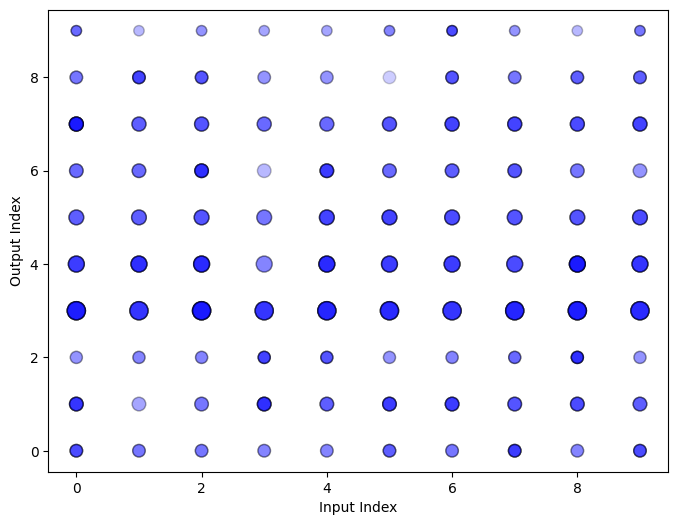

In [5]:
# Plot the results
x = input_index.detach()
y = output_index.detach()
sizes = torch.exp(logProb.detach()) * 1000  
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=sizes, color='blue', alpha=0.1, edgecolors='black')
plt.xlabel("Input Index")
plt.ylabel("Output Index")
plt.show()